# Setting up a GNN

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics as metrics
from sklearn.neighbors import kneighbors_graph

import torch
import torchinfo
import torch.nn as nn

from torch_geometric.nn import conv, global_mean_pool
from torch_geometric.nn.norm import BatchNorm
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

import uproot

## Checking available cpus/gpus

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


if device == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
elif device == 'mps':
    print('Using Apple Metal Performance Shaders')
else:
    print('Using CPU')

Using device: cpu
Using CPU


## Defining files and loading spacepoints

In [5]:
signal_name = "/exp/uboone/data/users/jbateman/workdir/DarkNews/Trident/SURPRISE/trident_SURPRISE_big_wirecell.root"
background_name = "/exp/uboone/data/users/jbateman/workdir/DarkNews/newSamplesWCepem/mcc910/checkout_MCC9.10_Run4b_v10_04_07_09_BNB_NC_pi0_overlay_surprise_reco2_hist.root"

nentries = 5000 # 

In [ ]:
def generic_neutrino_selection_spacepoints_vars(file, nentries=5000, spacepoint_type='recchargeblob', additional_keys=None):
    sp_df = pd.DataFrame()

    # To save on memory usage we only load the one type of spacepoint

    # Spacepoint_type can be either 'rec', 'reccharge', or 'recchargeblob'
    spacepoint_branches = [
        f'T{spacepoint_type}_spacepoints_x',    # the x position of the spacepoint (cm)
        f'T{spacepoint_type}_spacepoints_y',    # the y position of the spacepoint (cm)
        f'T{spacepoint_type}_spacepoints_z',    # the z position of the spacepoint (cm)
        f'Trecchargeblob_spacepoints_q',        # the charge of the spacepoint (uncalibrated but proportional to the energy deposited)
    ]
    
    # This is the CC muon interaction score. If we just require it to be more than zero or equal to zero
    # we get rid of any "bad" events (eg there isn't anything reconstructed) but don't actually make any cuts on the type of interaction. 
    # This is the so-called "generic neutrino selection".
    sp_df['numu_cc_flag'] = file['wcpselection/T_BDTvars']['numu_cc_flag'].array(entry_stop=nentries).to_list() 
    
    print(f"Loading spacepoint branches...")
    for branch in spacepoint_branches:
        sp_df[branch] = file['wcpselection/T_spacepoints'][branch].array(entry_stop=nentries).to_list()
        

    truth_vertex_branches = [           # from T_eval    
        "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
        "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
        "truth_vtxX",                   # true neutrino vertex x (cm)
        "truth_vtxY",                   # true neutrino vertex y (cm)
        "truth_vtxZ",                   # true neutrino vertex z (cm)
        "truth_nuPdg",                  # true neutrino PDG code
        "truth_nuEnergy",               # true neutrino energy (MeV)
        "truth_isCC",                   # boolean, true neutrino is charged current
        "run",                          # run number
        "subrun",                       # subrun number
        "event",                        # event number
        ]

    print(f"Loading truth vertex branches...")
    for branch in truth_vertex_branches:
        sp_df[branch] = file['wcpselection/T_eval'][branch].array(entry_stop=nentries).to_list()

    reco_vertex_branches = [                # from T_PFeval
        "reco_nuvtxX",                      # reconstructed neutrino vertex x (cm)
        "reco_nuvtxY",                      # reconstructed neutrino vertex y (cm)
        "reco_nuvtxZ",                      # reconstructed neutrino vertex z (cm)
        # # Including reco parent and pdg info
        "reco_id",                          # unique wire cell ID for each particle in the event  (completely independent from the truth_id)  
        "reco_pdg",                         # predicted particle PDG code for each particle in the event
        "reco_mother",                      # Wire Cell ID of the predicted parent particle for each particle in the event
        
        # These truth branches are kept in the T_PFeval tree
        "truth_id",                         # unique wire cell ID for each particle in the event (completely independent from the reco_id)
        "truth_pdg",                        # true pdg code for each particle in the event
        "truth_mother",                     # Wire Cell ID of the parent particle for each particle in the event (0 if the particle is primary)
        "truth_startXYZT",                  # true start position (x,y,z in cm) and time each particle in the event
    ]
    print(f"Loading reco vertex branches...")
    for branch in reco_vertex_branches:
        sp_df[branch] = file['wcpselection/T_PFeval'][branch].array(entry_stop=nentries).to_list()

    print("Loading additional branches...")
    if additional_keys is not None:
        for key, branches in additional_keys.items():
            for branch in branches:
                sp_df[branch] = file[f'wcpselection/{key}'][branch].array(entry_stop=nentries).to_list()
    
    print("Applying generic neutrino selection cuts...")
    print("Initial number of events:", len(sp_df))
    sp_df = sp_df[sp_df['numu_cc_flag'] >= 0]# .reset_index(drop=True)
    print("Number of events after generic cut:", len(sp_df))
    return sp_df

def proton_veto(df):
    df['proton_kine_indices'] = df['kine_particle_type'].apply(lambda x: np.argwhere(np.array(x) == 2212))
    drop_protons = []
    for e_arr, i in zip(df['kine_energy_particle'], df['proton_kine_indices']):
        drop_protons.append(np.sum(np.array(e_arr)[i] > 35) < 1)
    df = df[drop_protons]
    return df

def zero_proton_preselection(df):
    df = df[
        (df['stm_clusterlength'] > 0) &
        (df['match_isFC'] == 1) &
        (df['nue_score'] != -15)
    ]
    df = proton_veto(df)#.reset_index(drop=True)
    return df

In [34]:
spacepoint_type = 'recchargeblob' # can be either 'rec', 'reccharge', or 'recchargeblob'
apply_zero_proton_preselection = False

# Additional branches to load if you want to apply the zero proton preselection cuts.
additional_keys = {
    'T_BDTvars': [
        'nue_score',            # the BDT score for how "electron neutrino like" the event is (the event is bad if this is -15)
    ],
    'T_KINEvars': [
        'kine_particle_type',   # the PDG code for each particle in the event as determined by the kinematic reconstruction
        'kine_energy_particle', # the energy for each particle in the event as determined by the kinematic reconstruction
    ],
    'T_eval': [
        'stm_clusterlength',    # checking that there are reconstructed clusters in the event
        'match_isFC',           # checking that the event is fully contained within the detector
    ]
}

print("Loading signal spacepoints...")
signal_spacepoints_df = generic_neutrino_selection_spacepoints_vars(uproot.open(signal_name), nentries=nentries, spacepoint_type=spacepoint_type, additional_keys=additional_keys)
print("Loading background spacepoints...")
background_spacepoints_df = generic_neutrino_selection_spacepoints_vars(uproot.open(background_name), nentries=nentries, spacepoint_type=spacepoint_type, additional_keys=additional_keys)


if apply_zero_proton_preselection:
    print("Applying zero proton preselection to signal sample...")
    signal_spacepoints_df = zero_proton_preselection(signal_spacepoints_df)
    print(f'Signal sample after zero proton preselection: {len(signal_spacepoints_df)} events')
    print("Applying zero proton preselection to background sample...")
    background_spacepoints_df = zero_proton_preselection(background_spacepoints_df)
    print(f'Background sample after zero proton preselection: {len(background_spacepoints_df)} events')

Loading signal spacepoints...
Loading spacepoint branches...
Loading truth vertex branches...
Loading reco vertex branches...
Loading additional branches...
Applying generic neutrino selection cuts...
Initial number of events: 5000
Number of events after generic cut: 4028
Loading background spacepoints...
Loading spacepoint branches...
Loading truth vertex branches...
Loading reco vertex branches...
Loading additional branches...
Applying generic neutrino selection cuts...
Initial number of events: 5000
Number of events after generic cut: 3662


## Visualising events

### Point cloud

/tmp/ipykernel_3671051/2497786998.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


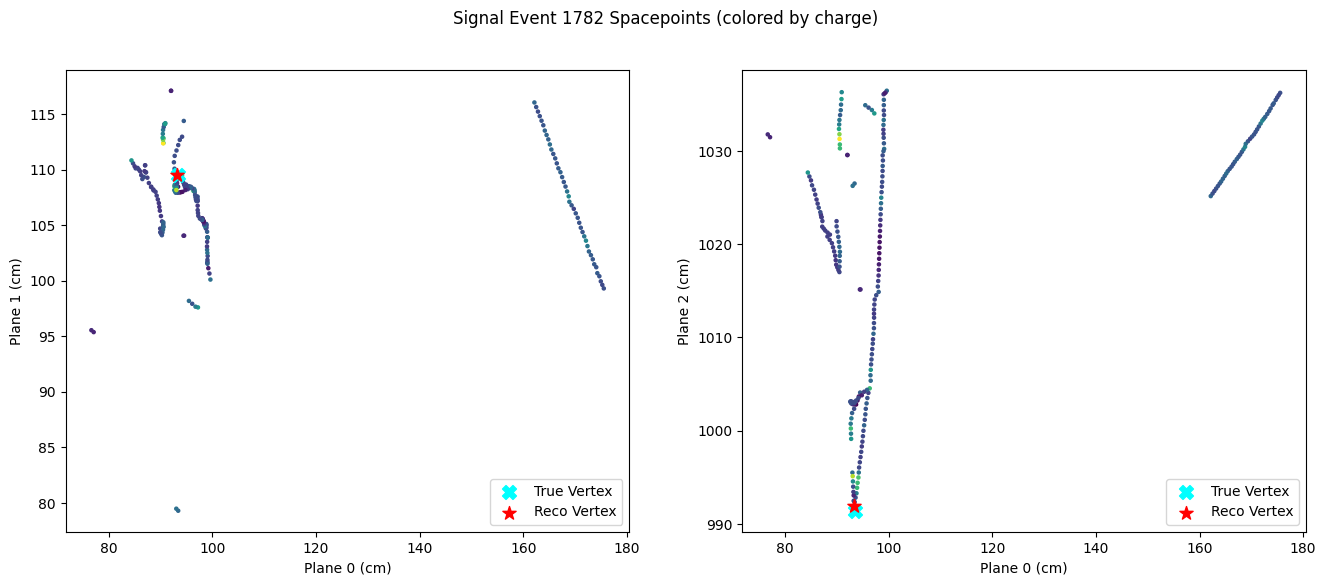

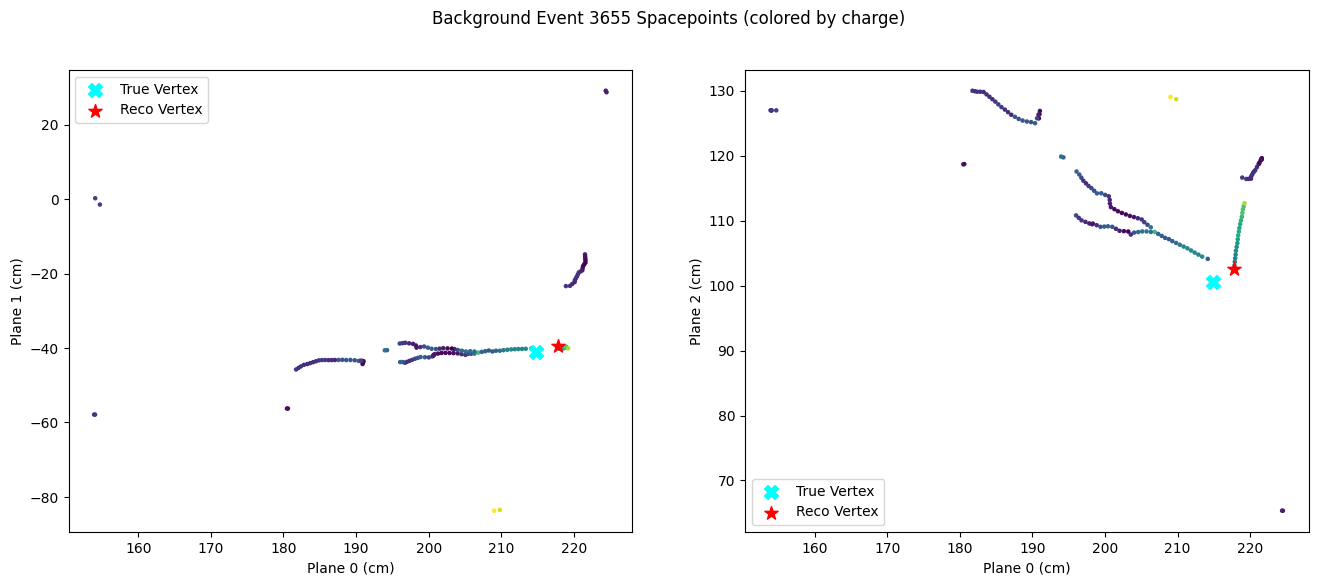

In [35]:
sig_event_index = 1782 # np.random.randint(0, len(signal_spacepoints_df))
bkg_event_index = 3655 # np.random.randint(0, len(background_spacepoints_df))

planes_to_plot = [0, 1, ] # pair of either x, y or z (0, 1, or 2)

def plot_spacepoints(df, event_index, spacepoint_type='recchargeblob', title_prefix=''):

    spacepoints = df.iloc[event_index][f'T{spacepoint_type}_spacepoints_x'], df.iloc[event_index][f'T{spacepoint_type}_spacepoints_y'], df.iloc[event_index][f'T{spacepoint_type}_spacepoints_z']
    charge = df.iloc[event_index][f'Trecchargeblob_spacepoints_q']

    true_vtx = (df.iloc[event_index]['truth_vtxX'], df.iloc[event_index]['truth_vtxY'], df.iloc[event_index]['truth_vtxZ'])
    reco_vtx = (df.iloc[event_index]['reco_nuvtxX'], df.iloc[event_index]['reco_nuvtxY'], df.iloc[event_index]['reco_nuvtxZ'])

    # Trident events don't have a proper true vertex assigned, so we find the outgoing neutrino ourselves
    if true_vtx[0] == 0 and true_vtx[1] == 0 and true_vtx[2] == 0:   
        truth_pdg = np.array(df.iloc[event_index]['truth_pdg'])
        neutrino_index= np.argwhere((truth_pdg == 12) | (truth_pdg == -12) | (truth_pdg == 14) | (truth_pdg == -14) | (truth_pdg == 16) | (truth_pdg == -16))[0]
        if neutrino_index.size > 0:
            truth_start = df.iloc[event_index]['truth_startXYZT'][neutrino_index[0]]
            true_vtx = (truth_start[0], truth_start[1], truth_start[2])
        else:
            print("No neutrino found in truth information for this event.")
            true_vtx = (np.nan, np.nan, np.nan)
    
    planes_left = [0, 1]
    planes_right = [0, 2]
    planes_to_plot = [planes_left, planes_right]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    for i in range(len(planes_to_plot)):
        plane_1 = spacepoints[planes_to_plot[i][0]]
        plane_2 = spacepoints[planes_to_plot[i][1]]

        ax[i].scatter(plane_1, plane_2, c=charge, cmap='viridis', s=5)
        ax[i].scatter(true_vtx[planes_to_plot[i][0]], true_vtx[planes_to_plot[i][1]], c='cyan', marker='X', s=100, label='True Vertex')
        ax[i].scatter(reco_vtx[planes_to_plot[i][0]], reco_vtx[planes_to_plot[i][1]], c='red', marker='*', s=100, label='Reco Vertex')
        ax[i].legend()    
        ax[i].set_xlabel(f'Plane {planes_to_plot[i][0]} (cm)')
        ax[i].set_ylabel(f'Plane {planes_to_plot[i][1]} (cm)')

    fig.suptitle(f'{title_prefix} Event {event_index} Spacepoints (colored by charge)')

    fig.show()

plot_spacepoints(signal_spacepoints_df, sig_event_index, spacepoint_type=spacepoint_type, title_prefix='Signal')
plot_spacepoints(background_spacepoints_df, bkg_event_index, spacepoint_type=spacepoint_type, title_prefix='Background')


### kNN Graph

You could also combine the list of edges with the the pointcloud to show these connections in 3D space, but I find it quite hard to parse.

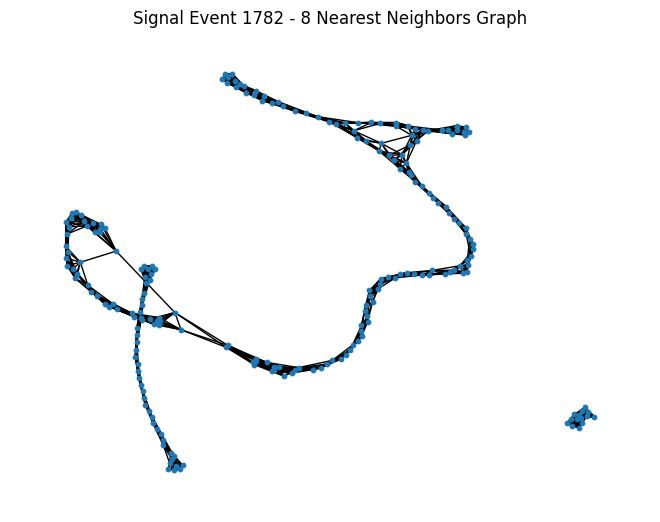

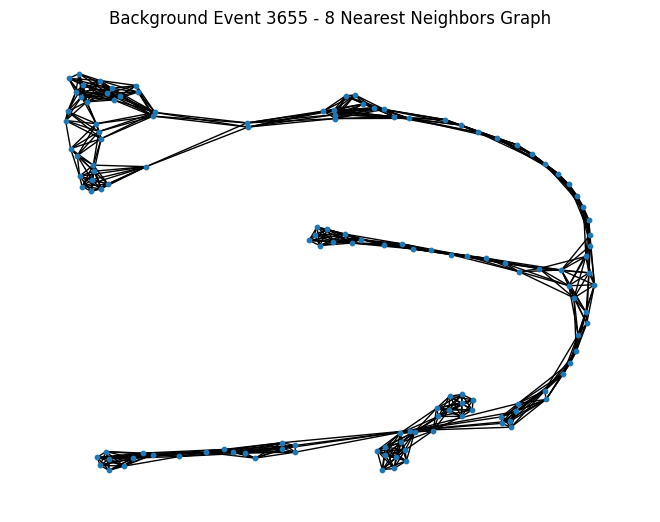

In [36]:
def make_a_kNN_graph(df, event_index, spacepoint_type='recchargeblob', k=8, title_prefix=''):
    spacepoints = df.iloc[event_index][f'T{spacepoint_type}_spacepoints_x'], df.iloc[event_index][f'T{spacepoint_type}_spacepoints_y'], df.iloc[event_index][f'T{spacepoint_type}_spacepoints_z']
    X = np.stack(spacepoints, axis=1)

    A_matrix = kneighbors_graph(X, n_neighbors=k, mode='connectivity', include_self=False).toarray()
    edges = np.array(np.nonzero(A_matrix)).T
    G = nx.from_edgelist(edges)
    nx.draw(G,  node_size=10)
    plt.title(f'{title_prefix} Event {event_index} - {k} Nearest Neighbors Graph')
    plt.show()

    return

make_a_kNN_graph(signal_spacepoints_df, sig_event_index, spacepoint_type=spacepoint_type, k=8, title_prefix='Signal')
make_a_kNN_graph(background_spacepoints_df, bkg_event_index, spacepoint_type=spacepoint_type, k=8, title_prefix='Background')

### (Optional) Use plotly to visualise in 3D

Commented out in case you don't have plotly

In [37]:
# from plotly import graph_objects as go

# def plot_spacepoints_3d(df, event_index, spacepoint_type='recchargeblob', title_prefix=''):
#     event = df.iloc[event_index]

#     true_vtx = (df.iloc[event_index]['truth_vtxX'], df.iloc[event_index]['truth_vtxY'], df.iloc[event_index]['truth_vtxZ'])
#     reco_vtx = (df.iloc[event_index]['reco_nuvtxX'], df.iloc[event_index]['reco_nuvtxY'], df.iloc[event_index]['reco_nuvtxZ'])

#     # Trident events don't have a proper true vertex assigned, so we find the outgoing neutrino ourselves
#     if true_vtx[0] == 0 and true_vtx[1] == 0 and true_vtx[2] == 0:   
#         truth_pdg = np.array(df.iloc[event_index]['truth_pdg'])
#         neutrino_index= np.argwhere((truth_pdg == 12) | (truth_pdg == -12) | (truth_pdg == 14) | (truth_pdg == -14) | (truth_pdg == 16) | (truth_pdg == -16))[0]
#         if neutrino_index.size > 0:
#             truth_start = df.iloc[event_index]['truth_startXYZT'][neutrino_index[0]]
#             true_vtx = (truth_start[0], truth_start[1], truth_start[2])
#         else:
#             print("No neutrino found in truth information for this event.")
#             true_vtx = (np.nan, np.nan, np.nan)

#     fig = go.Figure(data=[go.Scatter3d(
#         x=event[f'T{spacepoint_type}_spacepoints_x'],
#         y=event[f'T{spacepoint_type}_spacepoints_y'],
#         z=event[f'T{spacepoint_type}_spacepoints_z'],
#         mode='markers',
#         marker=dict(size=2, color=event[f'T{spacepoint_type}_spacepoints_q'], colorscale='Viridis', opacity=0.8)
#     )])

#     fig.add_trace(go.Scatter3d(
#         x=[true_vtx[0]],
#         y=[true_vtx[1]],
#         z=[true_vtx[2]],
#         mode='markers',
#         marker=dict(size=4, color='cyan', symbol='x'),
#         name='True Vertex'
#     ))

#     fig.add_trace(go.Scatter3d(
#         x=[reco_vtx[0]],
#         y=[reco_vtx[1]],
#         z=[reco_vtx[2]],
#         mode='markers',
#         marker=dict(size=4, color='red', symbol='diamond'),
#         name='Reco Vertex'
#     ))

#     fig.update_layout(
#                         title=f'{title_prefix} Event {event_index} Spacepoints (colored by charge)',
#                         width=800, height=800
#                         )

#     fig.update_scenes(aspectmode = "manual",
#     aspectratio = dict( x = 1, y = 1, z = 1), xaxis_title="X", yaxis_title="Y", zaxis_title="Z")
#     fig.show()

# plot_spacepoints_3d(signal_spacepoints_df, sig_event_index, spacepoint_type=spacepoint_type, title_prefix='Signal')
# plot_spacepoints_3d(background_spacepoints_df, bkg_event_index, spacepoint_type=spacepoint_type, title_prefix='Background')

## Formatting signal and background for loading

Here we turn each event into a graph, and store it in a torch_geometric "Data" object, which is designed to work with graphs and the torch_geometric "DataLoader" later on.

In [45]:
def printProgressBar (iteration, total, prefix = '', suffix = '', decimals = 1, length = 100, fill = '█', printEnd = "\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end = printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()


def make_spacepoint_array(df, use_q = True, flag = 0, radius_cut=-1, n_neighbors=8, spacepoint_type='recchargeblob', device=device):
    data_list = []
    nevents = 0
    N = 0
    i = 1
    for index, event in df.iterrows():
        nevents += 1 
    printProgressBar(0, nevents, prefix = 'Progress:', suffix = 'Complete', length = 50)
    for index, event in df.iterrows():
        nu_vertex = np.array([event['reco_nuvtxX'], event['reco_nuvtxY'], event['reco_nuvtxZ']])

        X = np.stack([event[f'T{spacepoint_type}_spacepoints_x'], event[f'T{spacepoint_type}_spacepoints_y'], event[f'T{spacepoint_type}_spacepoints_z']], axis=1)
        X = X - nu_vertex  # Center the spacepoints around the reconstructed neutrino vertex
        q = np.array(event[f'T{spacepoint_type}_spacepoints_q'])
        if radius_cut > 0:
            distances = np.linalg.norm(X, axis=1)
            mask = distances < radius_cut
            X = X[mask]
            q = q[mask]

        if len(X) > n_neighbors + 1:
            A_matrix = kneighbors_graph(X, n_neighbors=n_neighbors, mode='connectivity', include_self=False).toarray()
        elif len(X) < n_neighbors + 1 and len(X) > 1:  # If an event doesn't have enough spacepoints to make a kNN graph, we create a smaller, fully connected graph.
            # printProgressBar(i, nevents, prefix = 'Progress:', suffix = 'Complete', length = 50)
            A_matrix = kneighbors_graph(X, n_neighbors=min(n_neighbors, len(X)-1), mode='connectivity', include_self=False).toarray()
        elif len(X) == 1: 
            # If there is 1 spacepoints, we make an identity adjacency matrix
            A_matrix = np.array([[1]])

        else:
            # If there are no spacepoints, we have to skip this event. 
            printProgressBar(i, nevents, prefix = 'Progress:', suffix = 'Complete', length = 50)
            i+=1
            N += 1
            continue
            
        edges = np.array(np.nonzero(A_matrix)).T
        # weights = [q1*q2 for q1, q2 in zip(q[edges[:,0]], q[edges[:,1]])]
        X_plus_q = np.hstack((X, q.reshape(-1, 1))) if use_q else X

        event = Data(x=torch.tensor(X_plus_q, dtype=torch.float).to(device), edge_index=torch.tensor(edges.T, dtype=torch.long).to(device), y=torch.tensor(flag, dtype=torch.long).to(device), nu_vertex=torch.tensor(nu_vertex, dtype=torch.float).to(device))
        data_list.append(event)
        printProgressBar(i, nevents, prefix = 'Progress:', suffix = 'Complete', length = 50)
        i += 1
    print(f'Number of events with no spacepoints: {N}')
    return data_list

In [55]:
merged_samples = []
sample_arr = []

use_q = True    # Use charge information as a node feature in addition to the x,y,z position of the spacepoints
n_neighbors = 8
radius_cut = 100 # cm, Cut spacepoints that are farther than this distance from the reconstructed neutrino vertex. Set to -1 to disable.

frac_train = 0.7
val_test_split = 0.5

if use_q:
    N_dims = 4  # x, y, z, q
else:
    N_dims = 3  # x, y, z

for i, sample in enumerate([background_spacepoints_df, signal_spacepoints_df]):
    print(f"Turning sample {i+1}/2 into graphs...")
    flag = i # 0 for background, 1 for signal
    data_list = make_spacepoint_array(sample, use_q=use_q, flag=flag, radius_cut=radius_cut, n_neighbors=n_neighbors, spacepoint_type=spacepoint_type, device=device)
    # all_samples.extend(data_list)
    sample_arr.append(data_list)
    print(f"Sample {i+1}/2 complete. Number of graphs: {len(data_list)}")

# To avoid issues with class imbalance, we take the smaller of the two samples and only use that many graphs from each sample.
min_len = min(len(sample) for sample in sample_arr)
print(f"Using {min_len} graphs from each sample to avoid class imbalance issues.")
for sample in sample_arr:
    merged_samples.extend(sample[:min_len])


print(f"Total number of graphs: {len(merged_samples)}")

print("Splitting data into train, test, and validation sets...")
train_sample, test_val_sample = train_test_split(merged_samples, test_size=1-frac_train, random_state=42)
test_sample, val_sample = train_test_split(test_val_sample, test_size=val_test_split, random_state=42)

print(f"Number of training graphs: {len(train_sample)}")
print(f"Number of validation graphs: {len(val_sample)}")
print(f"Number of testing graphs: {len(test_sample)}")

Turning sample 1/2 into graphs...
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Number of events with no spacepoints: 5
Sample 1/2 complete. Number of graphs: 3657
Turning sample 2/2 into graphs...
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Number of events with no spacepoints: 9
Sample 2/2 complete. Number of graphs: 4019
Using 3657 graphs from each sample to avoid class imbalance issues.
Total number of graphs: 7314
Splitting data into train, test, and validation sets...
Number of training graphs: 5119
Number of validation graphs: 1098
Number of testing graphs: 1097


## Creating a Graph Neural Network

In [56]:
class GNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super(GNNClassifier, self).__init__()
        # input shape (batch, num_nodes, input_dim)

        self.init_batch_norm = BatchNorm(input_dim)

        conv_layers = []
        if isinstance(hidden_dims, int):
            gnn_conv = conv.GraphConv(input_dim, hidden_dims)
            batch_norm = BatchNorm(hidden_dims)
            activation = nn.ReLU()
            conv_layers.append((gnn_conv, batch_norm, activation))
            input_dim = hidden_dims
        else:
            for hidden_dim in hidden_dims:
                gnn_conv = conv.GraphConv(input_dim, hidden_dim)
                batch_norm = BatchNorm(hidden_dim)
                activation = nn.ReLU()
                conv_layers.append((gnn_conv, batch_norm, activation))
                input_dim = hidden_dim
        self.conv_layers = nn.ModuleList([nn.ModuleList(layer) for layer in conv_layers])
        

    
        self.output_layer = nn.Linear(input_dim, output_dim)
        self.output_activation = nn.Sigmoid() if output_dim == 1 else nn.Softmax(dim=1)

    def forward(self, data, edges, batch_indices, skip_output_activation=False):
        # We include an option to skip the output activation function because some loss functions (eg BCEWithLogitsLoss) expect raw logits as input.
        x = self.init_batch_norm(data)

        for gnn_conv, batch_norm, activation in self.conv_layers:
            x = gnn_conv(x, edges)
            x = batch_norm(x)
            x = activation(x)

        x = global_mean_pool(x, batch_indices) 
        x = self.output_layer(x)

        if not skip_output_activation:
            x = self.output_activation(x)
        return x

In [57]:
input_dim = N_dims  # x, y, z, q
conv_layer_dims = [8, 16, 32]

model = GNNClassifier(input_dim=input_dim, hidden_dims=conv_layer_dims, output_dim=1).to(device)

dummy_data = torch.randn((10, input_dim)).to(device)  # 10 nodes, input_dim features
dummy_edges = torch.tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
                            [1, 0, 3, 2, 5, 4, 7, 6, 9, 8]], dtype=torch.long).to(device)  # example edge index
dummy_batch = torch.zeros(10, dtype=torch.long).to(device)  # all nodes belong to the same graph
dummy_nu_vertex = torch.randn((1,3)).to(device)  # example neutrino vertex
torchinfo.summary(model, input_data=(dummy_data, dummy_edges, dummy_batch))

Layer (type:depth-idx)                   Output Shape              Param #
GNNClassifier                            [1, 1]                    --
├─BatchNorm: 1-1                         [10, 4]                   --
│    └─BatchNorm1d: 2-1                  [10, 4]                   8
├─ModuleList: 1-2                        --                        --
│    └─ModuleList: 2-2                   --                        --
│    │    └─GraphConv: 3-1               [10, 8]                   72
│    │    └─BatchNorm: 3-2               [10, 8]                   16
│    │    └─ReLU: 3-3                    [10, 8]                   --
│    └─ModuleList: 2-3                   --                        --
│    │    └─GraphConv: 3-4               [10, 16]                  272
│    │    └─BatchNorm: 3-5               [10, 16]                  32
│    │    └─ReLU: 3-6                    [10, 16]                  --
│    └─ModuleList: 2-4                   --                        --
│    │    └─Gra

In [58]:
batch_size = 32
nepochs = 10

lr = 1e-3
gamma = 1 # learning rate decay factor, set to 1 to disable decay

optimizer = torch.optim.RAdam(model.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)  # Define learning rate scheduler.

if scheduler is not None and gamma != 1:
    print('Using learning rate scheduler with gamma =', gamma)
    x = np.linspace(1, nepochs, nepochs)
    f = lambda l: lr * (gamma ** (l - 1))
    y = f(x)
    plt.plot(x, y)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.show()

train_loader = DataLoader(train_sample, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_sample, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_sample, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

model_states = []

for epoch in range(nepochs):
    print(f'Epoch {epoch+1}/{nepochs}')
    if scheduler is not None and gamma != 1:
        print(f'Learning Rate: {optimizer.param_groups[0]["lr"]:.2e}')
    printProgressBar(0, len(train_loader), prefix = 'Progress:', suffix = 'Complete', length = 50)

    model.train()
    epoch_loss = 0
    epoch_acc = 0
    train_loader = DataLoader(train_sample, batch_size=batch_size, shuffle=True) # Shuffle training data at the beginning of each epoch
    j = 1
    for batch in train_loader:
        optimizer.zero_grad()

        # Note here that we are passing skip_output_activation=True to the model's forward function.
        # This is because we are using BCEWithLogitsLoss as our loss function, which expects
        # raw logits rather than a score between 0 and 1. Using logits in loss leads to more numerically stable training.
        outputs = model(batch.x, batch.edge_index, batch.batch, skip_output_activation=True)
        scores = torch.sigmoid(outputs).squeeze()
        loss = criterion(outputs.squeeze(), batch.y.float())
        loss.backward()
        optimizer.step()

        loss_value = loss.mean().item()
        epoch_loss += loss_value
        acc = ((scores > 0.5) == batch.y).float().mean().item()
        epoch_acc += acc

        printProgressBar(j, len(train_loader), prefix = 'Progress:', suffix = 'Complete', length = 50)
        j += 1
    epoch_loss /= len(train_loader)
    epoch_acc /= len(train_loader)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    model_states.append(model.state_dict())

    # Validation
    model.eval()
    epoch_val_loss = 0
    epoch_val_acc = 0
    for batch in val_loader:
        with torch.no_grad():
            outputs = model(batch.x, batch.edge_index, batch.batch, skip_output_activation=True)
            scores = torch.sigmoid(outputs).squeeze()
            loss = criterion(outputs.squeeze(), batch.y.float())
            preds = (scores > 0.5).long()
            acc = (preds == batch.y).float().mean().item()
            epoch_val_acc += acc
            epoch_val_loss += loss.mean().item()
    epoch_val_loss /= len(val_loader)
    epoch_val_acc /= len(val_loader)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step() if scheduler is not None and gamma != 1 else None
    print(f"Epoch {epoch+1}/{nepochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")


Epoch 1/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 1/10 - Train Loss: 0.6349, Train Acc: 0.6984, Val Loss: 0.5773, Val Acc: 0.8070
Epoch 2/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 2/10 - Train Loss: 0.5246, Train Acc: 0.8197, Val Loss: 0.4578, Val Acc: 0.8255
Epoch 3/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 3/10 - Train Loss: 0.4167, Train Acc: 0.8504, Val Loss: 0.3747, Val Acc: 0.8525
Epoch 4/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 4/10 - Train Loss: 0.3538, Train Acc: 0.8668, Val Loss: 0.3340, Val Acc: 0.8730
Epoch 5/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 5/10 - Train Loss: 0.3336, Train Acc: 0.8633, Val Loss: 0.3177, Val Acc: 0.8721
Epoch 6/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 6/10 - Train Loss: 0.321

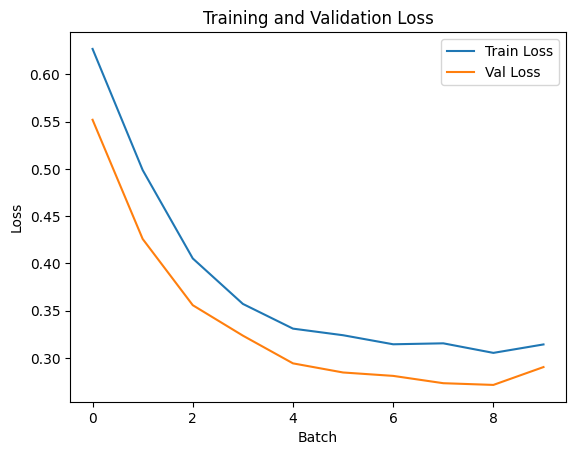

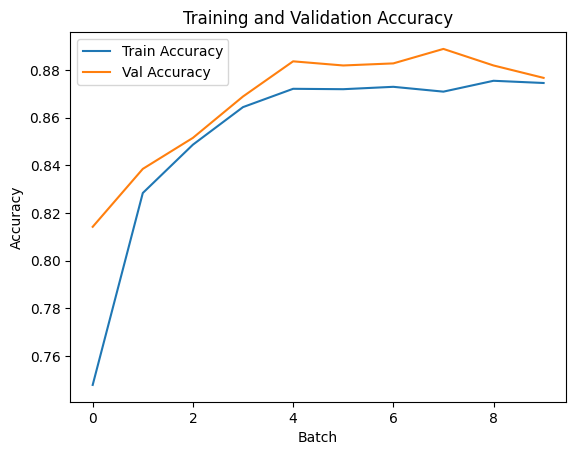

In [50]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Batch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

## Evaluating the model
### Grabbing the epoch that minimised loss or maxismised accuracy.

Best model found at epoch 8 with validation loss 0.2993 and validation accuracy 0.8775
Test Accuracy: 0.8797


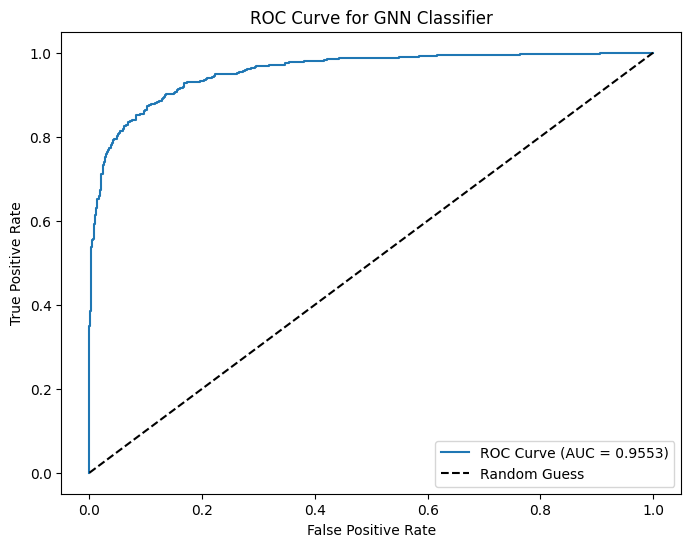

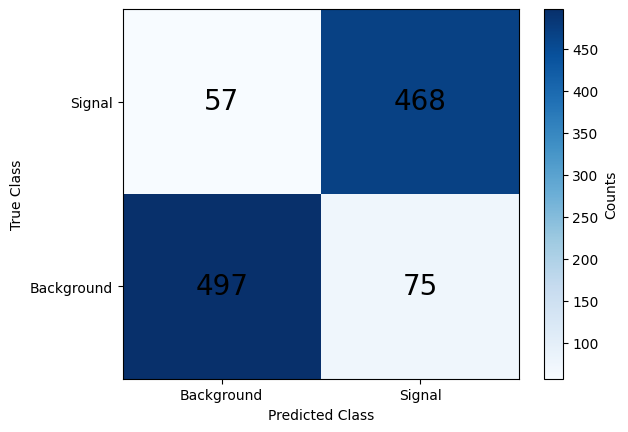

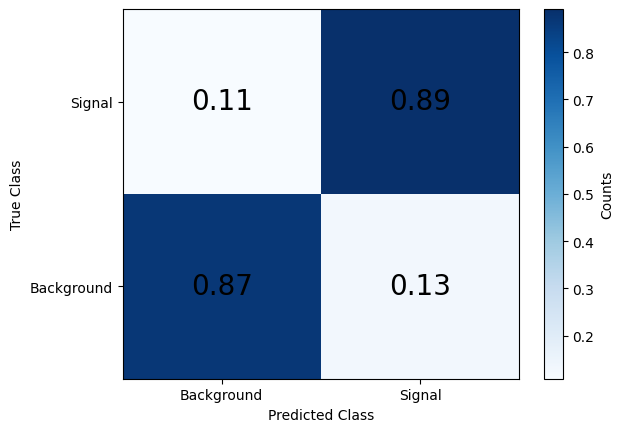

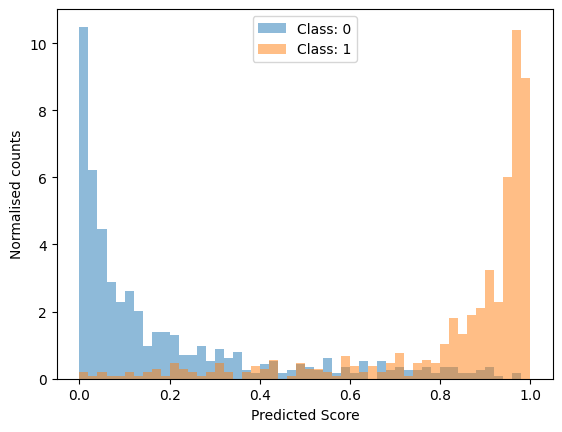

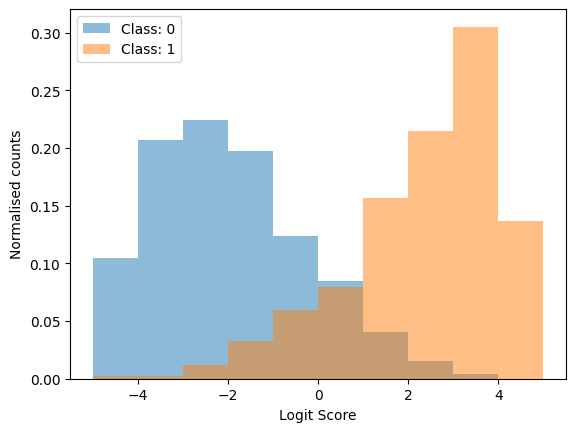

In [59]:
optimal_epoch = np.argmin(val_losses) # Decide how to choose the optimal epoch - np.argmin(val_losses) or np.argmax(val_accuracies)
print(f"Best model found at epoch {optimal_epoch+1} with validation loss {val_losses[optimal_epoch]:.4f} and validation accuracy {val_accuracies[optimal_epoch]:.4f}")
best_model_state = model_states[optimal_epoch]
model.load_state_dict(best_model_state)


test_flags = []
test_scores = []
for batch in test_loader:
    model.eval()
    with torch.no_grad():
        outputs = model(batch.x, batch.edge_index, batch.batch, skip_output_activation=True)
        scores = torch.sigmoid(outputs).squeeze()
        test_scores.extend(scores.cpu().numpy())
        test_flags.extend(batch.y.cpu().numpy())

test_acc = ((np.array(test_scores) > 0.5) == np.array(test_flags)).mean()
print(f"Test Accuracy: {test_acc:.4f}")

roc_curve = metrics.roc_curve(test_flags, test_scores)
auc_score = metrics.auc(roc_curve[0], roc_curve[1])

plt.figure(figsize=(8, 6))
plt.plot(roc_curve[0], roc_curve[1], label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for GNN Classifier')
plt.legend()  
plt.show()    

predicted_class = (np.array(test_scores) >= 0.5).astype(int)
confusion_matrix_arrs = metrics.confusion_matrix(test_flags, predicted_class)
norm_conf_matrix = confusion_matrix_arrs / np.sum(confusion_matrix_arrs, axis=1, keepdims=True)

plt.pcolormesh(confusion_matrix_arrs, cmap='Blues', shading='auto')
plt.xticks([0.5, 1.5], ['Background', 'Signal'])
plt.yticks([0.5, 1.5], ['Background', 'Signal'])
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.5, confusion_matrix_arrs[i, j], ha='center', va='center', color='black', fontsize=20)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.colorbar(label='Counts')
plt.show()

plt.pcolormesh(norm_conf_matrix, cmap='Blues', shading='auto')
plt.xticks([0.5, 1.5], ['Background', 'Signal'])
plt.yticks([0.5, 1.5], ['Background', 'Signal'])
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.5, f'{norm_conf_matrix[i, j]:.2f}', ha='center', va='center', color='black', fontsize=20)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.colorbar(label='Counts')
plt.show()


bins = np.linspace(0, 1, 51)
for cls_type in np.unique(test_flags):
    cls_mask = np.array(test_flags) == cls_type
    cls_preds = np.array(test_scores)[cls_mask]
    plt.hist(cls_preds, bins=bins, alpha=0.5, density=True, label=f'Class: {int(cls_type)}')
plt.xlabel('Predicted Score')
plt.ylabel('Normalised counts')
plt.legend()
plt.show()

logit_score = np.log(np.array(test_scores) / (1 - np.array(test_scores)))
bins = np.linspace(-5, 5, 11)
for cls_type in np.unique(test_flags):
    cls_mask = np.array(test_flags) == cls_type
    cls_preds = logit_score[cls_mask]
    plt.hist(cls_preds, bins=bins, alpha=0.5, density=True, label=f'Class: {int(cls_type)}')
plt.xlabel('Logit Score')
plt.ylabel('Normalised counts')
plt.legend()
plt.show()

## Testing on Nu Overlay

How does this perform on the full nu overlay background sample?

In [60]:
overlay_name = "/exp/uboone/data/users/jbateman/workdir/DarkNews/newSamplesWCepem/mcc910/checkout_MCC9.10_Run4b_v10_04_07_09_BNB_nu_overlay_surprise_reco2_hist.root"
nentries_overlay = 1000
print("Loading overlay spacepoints...")
overlay_spacepoints_df = generic_neutrino_selection_spacepoints_vars(uproot.open(overlay_name), nentries=nentries_overlay, spacepoint_type=spacepoint_type)
print("Turning overlay sample into graphs...")
overlay_data_list = make_spacepoint_array(overlay_spacepoints_df, use_q=use_q, flag=-1, radius_cut=radius_cut, n_neighbors=n_neighbors, spacepoint_type=spacepoint_type, device=device)
print(f"Overlay sample complete. Number of graphs: {len(overlay_data_list)}")
overlay_loader = DataLoader(overlay_data_list, batch_size=batch_size, shuffle=False)

Loading overlay spacepoints...
Loading spacepoint branches...
Loading truth vertex branches...
Loading reco vertex branches...
Loading additional branches...
Applying generic neutrino selection cuts...
Initial number of events: 1000
Number of events after generic cut: 316
Turning overlay sample into graphs...
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Number of events with no spacepoints: 1
Overlay sample complete. Number of graphs: 315


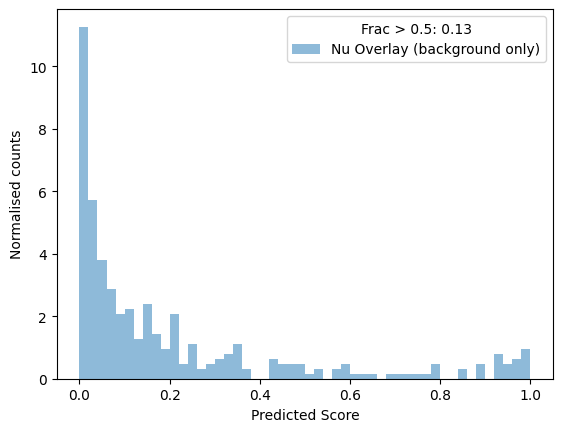

In [61]:
overlay_scores = []
for batch in overlay_loader:
    model.eval()
    with torch.no_grad():
        outputs = model(batch.x, batch.edge_index, batch.batch, skip_output_activation=True)
        scores = torch.sigmoid(outputs).squeeze()
        overlay_scores.extend(scores.cpu().numpy())

bins = np.linspace(0, 1, 51)

plt.hist(overlay_scores, bins=bins, alpha=0.5, density=True, label=f'Nu Overlay (background only)')
plt.xlabel('Predicted Score')
plt.ylabel('Normalised counts')
plt.legend(title=f'Frac > 0.5: {sum(np.array(overlay_scores) > 0.5) / len(overlay_scores):.2f}')
plt.show()